In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy

In [2]:
### let's load the data

### this line assumes that const_data.txt and this notebook are in the same folder.
const_data = np.loadtxt('const_data.txt')

Xs, Ys, sigs = const_data.T

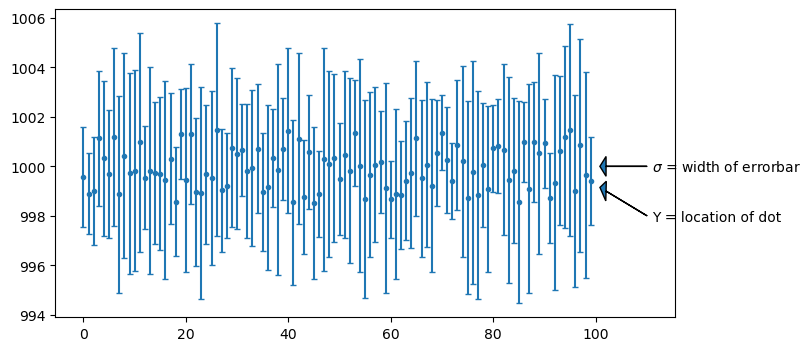

In [4]:
### let's plot the data

fig, axs = plt.subplots(1, 1, figsize=(8, 4))

axs.errorbar(Xs, Ys, yerr=sigs, capsize=2., marker='.', linestyle='None');

axs.arrow(110, 1000, -8, 0, head_width=0.8)
axs.text(111, 999.8, '$\\sigma$ = width of errorbar');

axs.arrow(110, 998, -8, 1, head_width=0.8)
axs.text(111, 997.8, 'Y = location of dot');

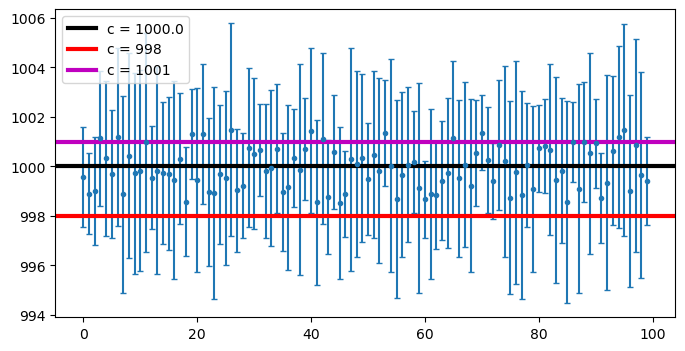

In [5]:
### let's plot the data and guess a couple of lines:

fig, axs = plt.subplots(1, 1, figsize=(8, 4))

axs.errorbar(Xs, Ys, yerr=sigs, capsize=2., marker='.', linestyle='None');

### the equation for a line is m*x + b
c = 1e3
axs.axhline(y=c, color='k', linewidth=3., label='c = {}'.format(c));

c = 998
axs.axhline(y=c, color='r', linewidth=3., label='c = {}'.format(c));

c = 1001
axs.axhline(y=c, color='m', linewidth=3., label='c = {}'.format(c));

axs.legend();

In [6]:
def chi2_const(parameters): ### parameters is a list of numbers that appear in your P_i, but for this case we just have P_i = c
    c = parameters[0]

    chi2 = np.sum(pow((Ys - c)/sigs, 2))
    return chi2

In [7]:
const_guess = [1000.]

optimal_const = scipy.optimize.minimize(chi2_const, const_guess, method='nelder-mead')

In [8]:
optimal_const

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 11.033271590379105
             x: [ 9.999e+02]
           nit: 20
          nfev: 40
 final_simplex: (array([[ 9.999e+02],
                       [ 9.999e+02]]), array([ 1.103e+01,  1.103e+01]))

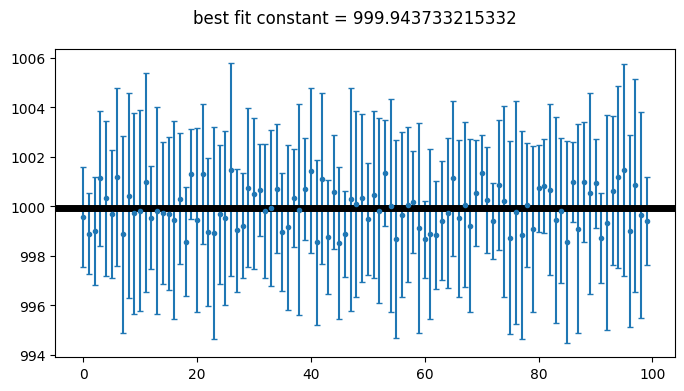

In [24]:
fig, axs = plt.subplots(1, 1, figsize=(8, 4))

axs.errorbar(Xs, Ys, yerr=sigs, capsize=2., marker='.', linestyle='None');

best_fit_const = optimal_const.x[0]
axs.axhline(best_fit_const, color='k', linewidth=5.);
fig.suptitle('best fit constant = {}'.format(best_fit_const));